# Decision Tree for Rainfall Classification

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import basic libraries
from pathlib import Path
import warnings

# Ignore unnecessary warnings to keep output clean
warnings.filterwarnings("ignore")

# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning utilities
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score

# Evaluation metrics for model performance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Preprocessing and model
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Display settings (for better readability)
plt.rcParams["figure.figsize"] = (8, 5)   # Set default plot size
pd.set_option("display.max_columns", None)  # Show all columns in dataframe

In [ ]:
# Load dataset from Google Drive

# Path to the encoded dataset file
data_path = '/content/drive/MyDrive/ML-Encorded-Dataset/sri_lanka_weather_encoded.csv'

# Read CSV file into a pandas DataFrame
df = pd.read_csv(data_path)

# Basic dataset inspection
print("Loaded file:", data_path)
print("Shape:", df.shape)
display(df.head())

Loaded file: /content/drive/MyDrive/ML-Encorded-Dataset/sri_lanka_weather_encoded.csv
Shape: (147480, 56)


,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,et0_fao_evapotranspiration,elevation,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos,rainfall_class,rainfall_class_encoded,city_Athurugiriya,city_Badulla,city_Bentota,city_Colombo,city_Galle,city_Gampaha,city_Hambantota,city_Hatton,city_Jaffna,city_Kalmunai,city_Kalutara,city_Kandy,city_Kesbewa,city_Kolonnawa,city_Kurunegala,city_Mabole,city_Maharagama,city_Mannar,city_Matale,city_Matara,city_Moratuwa,city_Mount Lavinia,city_Negombo,city_Oruwala,city_Pothuhera,city_Puttalam,city_Ratnapura,city_Sri Jayewardenepura Kotte,city_Trincomalee,city_Weligama
0,2.0,30.0,22.7,26.1,34.4,25.2,29.2,20.92,0.0,11.7,27.4,4.58,16.0,2010.0,1.0,1.0,4.0,1.0,0.0,11.716667,0.5,0.866025,0.342020,0.939693,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,51.0,29.9,23.5,26.2,33.8,26.2,29.8,17.71,1.0,13.0,27.0,3.84,16.0,2010.0,1.0,2.0,5.0,1.0,1.0,11.733333,0.5,0.866025,0.406737,0.913545,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,51.0,29.5,23.2,26.0,34.3,26.3,29.9,17.76,3.0,12.3,27.4,3.65,16.0,2010.0,1.0,3.0,6.0,1.0,1.0,11.716667,0.5,0.866025,0.275637,0.961262,Light Rain,1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2.0,28.9,21.9,25.3,31.6,23.4,27.8,16.50,0.0,17.0,34.6,3.79,16.0,2010.0,1.0,4.0,0.0,1.0,0.0,11.733333,0.5,0.866025,-0.069756,0.997564,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1.0,28.1,21.3,24.5,30.1,23.1,26.1,23.61,0.0,18.7,37.1,4.97,16.0,2010.0,1.0,5.0,1.0,1.0,0.0,11.733333,0.5,0.866025,-0.087156,0.996195,No Rain,3,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Identify target column

# Possible target column names (depending on preprocessing)
possible_targets = ["rainfall_class_encoded", "rainfall_class"]

# Select the first matching target column from dataset
target_col = next((c for c in possible_targets if c in df.columns), None)

# Stop execution if target column is not found
if target_col is None:
    raise ValueError("Target column not found. Expected 'rainfall_class_encoded' or 'rainfall_class'.")

In [ ]:
# Handle target encoding

class_names = None

# If target is not encoded, apply Label Encoding
if target_col == "rainfall_class":
    le = LabelEncoder()
    df[target_col] = le.fit_transform(df[target_col])
    class_names = list(le.classes_)

    print("Encoded rainfall_class automatically.")
    print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# If already encoded, just extract unique class labels
else:
    class_names = [str(c) for c in sorted(df[target_col].unique())]

In [ ]:
# Separate features (X) and target (y)

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

# Print useful information
print("Feature matrix (X) shape :", X.shape)
print("Target vector (y) shape  :", y.shape)

print("\nNumber of features       :", X.shape[1])
print("Number of samples        :", X.shape[0])

print("\nTarget column name       :", target_col)
print("Unique target classes    :", sorted(y.unique()))

Feature matrix (X) shape : (147480, 55)
Target vector (y) shape  : (147480,)

Number of features       : 55
Number of samples        : 147480

Target column name       : rainfall_class_encoded
Unique target classes    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [ ]:
# Handle boolean features

# Convert True/False columns to 0/1 (important for ML models)
bool_cols = X.select_dtypes(include=["bool"]).columns.tolist()
if bool_cols:
    X[bool_cols] = X[bool_cols].astype(int)
    print("Converted boolean columns to integers:", bool_cols)

# Remove unsupported non-numeric features

# ML models require numeric input → drop remaining object/string columns
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print("Dropping unsupported non-numeric feature columns:", non_numeric)
    X = X.drop(columns=non_numeric)

# Final dataset check

# Show final feature shape after cleaning
print("Feature shape:", X.shape)

# Display class distribution (important for imbalance checking)
print("\nTarget distribution:")
print(y.value_counts().sort_index())


Converted boolean columns to integers: ['city_Athurugiriya', 'city_Badulla', 'city_Bentota', 'city_Colombo', 'city_Galle', 'city_Gampaha', 'city_Hambantota', 'city_Hatton', 'city_Jaffna', 'city_Kalmunai', 'city_Kalutara', 'city_Kandy', 'city_Kesbewa', 'city_Kolonnawa', 'city_Kurunegala', 'city_Mabole', 'city_Maharagama', 'city_Mannar', 'city_Matale', 'city_Matara', 'city_Moratuwa', 'city_Mount Lavinia', 'city_Negombo', 'city_Oruwala', 'city_Pothuhera', 'city_Puttalam', 'city_Ratnapura', 'city_Sri Jayewardenepura Kotte', 'city_Trincomalee', 'city_Weligama']
Dropping unsupported non-numeric feature columns: ['rainfall_class']
Feature shape: (147480, 54)

Target distribution:
rainfall_class_encoded
0     9349
1    69341
2    42063
3    26727
Name: count, dtype: int64


In [ ]:
# Train-test split

# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(y_train.shape)

# Initialize Decision Tree model
tree_model = DecisionTreeClassifier(
    random_state=42,          # Ensures reproducibility
    class_weight="balanced",  # Handles class imbalance
    criterion="gini",         # Splitting metric (Gini impurity)
    max_depth=10,             # Controls tree complexity (prevents overfitting)
    min_samples_split=10,     # Minimum samples required to split a node
    min_samples_leaf=5        # Minimum samples required at a leaf node
)

(117984, 54)
(117984,)


In [ ]:
# Train the model
# Fit model using training data
tree_model.fit(X_train, y_train)

# Make predictions
# Predict on unseen test data
y_pred = tree_model.predict(X_test)

# Model evaluation
print("Train accuracy       :", round(tree_model.score(X_train, y_train), 4))        # check for overfitting
print("Test accuracy        :", round(accuracy_score(y_test, y_pred), 4))            # main performance metric
print("Balanced accuracy    :", round(balanced_accuracy_score(y_test, y_pred), 4))   # important for imbalanced datasets
print("Macro F1 score       :", round(f1_score(y_test, y_pred, average="macro"), 4)) # treats all classes equally

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))

Train accuracy       : 0.913
Test accuracy        : 0.9064
Balanced accuracy    : 0.91
Macro F1 score       : 0.8699

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.91      0.70      1870
           1       0.97      0.94      0.95     13868
           2       0.87      0.79      0.83      8413
           3       1.00      1.00      1.00      5345

    accuracy                           0.91     29496
   macro avg       0.85      0.91      0.87     29496
weighted avg       0.92      0.91      0.91     29496



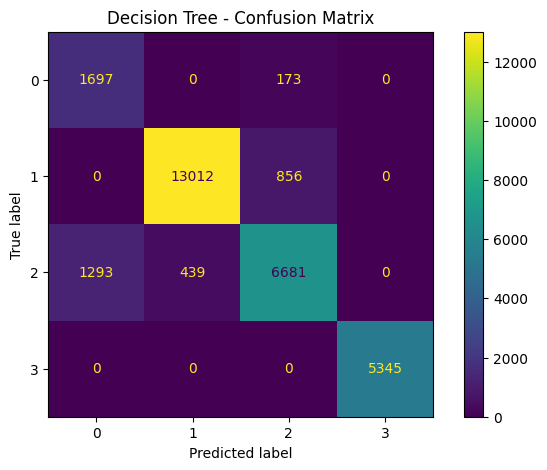

In [ ]:
# Confusion Matrix Visualization

# Compute confusion matrix using actual and predicted values
cm = confusion_matrix(y_test, y_pred)

# Create a display object with class labels for better readability
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

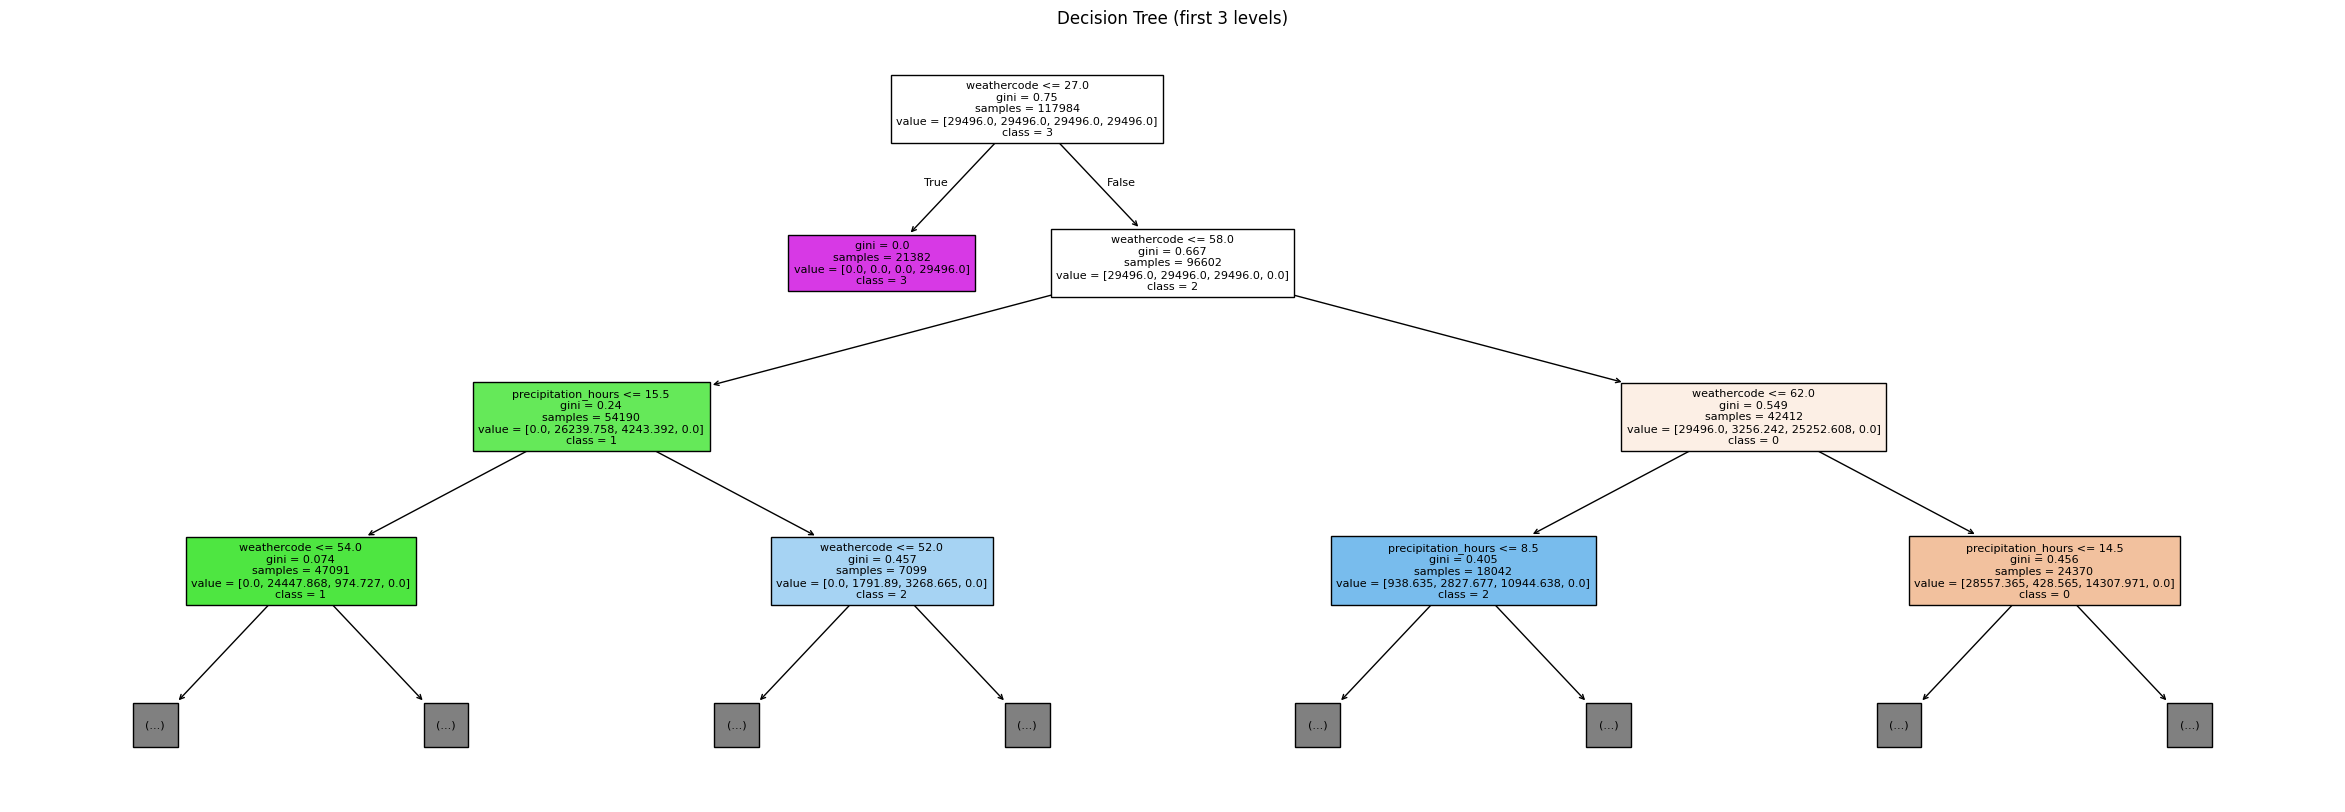

In [ ]:
# Decision Tree Visualization

# Create a large figure for better readability of the tree
plt.figure(figsize=(30, 10))

# Plot the decision tree - only first 3 levels
plot_tree(
    tree_model,
    filled=True,                                # Color nodes based on class
    max_depth=3,                                # Show only top levels (avoids clutter)
    feature_names=X.columns,                    # Display feature names in nodes
    class_names=[str(c) for c in class_names],  # Display class labels
    fontsize=8                                  # Adjust text size for readability
)

plt.title("Decision Tree (first 3 levels)")
plt.show()

In [ ]:
# Cross-Validation Setup
# Stratified K-Fold ensures each fold has similar class distribution
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform Cross-Validation
cv_accuracy = cross_val_score(tree_model, X, y, cv=cv, scoring="accuracy")
cv_balanced = cross_val_score(tree_model, X, y, cv=cv, scoring="balanced_accuracy")
cv_f1_macro = cross_val_score(tree_model, X, y, cv=cv, scoring="f1_macro")

print("CV accuracy scores        :", np.round(cv_accuracy, 4))
print("Mean CV accuracy          :", round(cv_accuracy.mean(), 4))
print("Mean CV balanced accuracy :", round(cv_balanced.mean(), 4))
print("Mean CV macro F1          :", round(cv_f1_macro.mean(), 4))

CV accuracy scores        : [0.9082 0.9042 0.9003 0.908  0.9096]
Mean CV accuracy          : 0.906
Mean CV balanced accuracy : 0.9111
Mean CV macro F1          : 0.8694


In [ ]:
# Define hyperparameter search space

# Different parameter values are tested to find the best Decision Tree model
param_grid = {
    "criterion": ["gini", "entropy"],       # Splitting criteria
    "max_depth": [5, 10, 15, 20, None],     # Maximum depth of the tree
    "min_samples_split": [2, 5, 10, 20],    # Minimum samples required to split a node
    "min_samples_leaf": [1, 2, 5, 10],      # Minimum samples required in a leaf node
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01]  # Pruning parameter
}


# Set up Grid Search
# GridSearchCV tests all parameter combinations using cross-validation
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=3,               # 3-fold cross-validation
    scoring="f1_macro", # Use macro F1 as the evaluation metric
    n_jobs=-1           # Use all available CPU cores
)

# Train model with hyperparameter tuning

grid.fit(X_train, y_train)            # Fit grid search on training data
best_tree = grid.best_estimator_      # Get the best tuned model
best_pred = best_tree.predict(X_test) # Make predictions using the tuned model

# Evaluate tuned model performance
print("Best parameters        :", grid.best_params_)
print("Best CV macro F1       :", round(grid.best_score_, 4))
print("Tuned test accuracy    :", round(accuracy_score(y_test, best_pred), 4))
print("Tuned balanced accuracy:", round(balanced_accuracy_score(y_test, best_pred), 4))
print("Tuned macro F1         :", round(f1_score(y_test, best_pred, average="macro"), 4))

# Display detailed performance for each class
print("\nTuned Classification Report:")
print(classification_report(y_test, best_pred, target_names=[str(c) for c in class_names]))

Best parameters        : {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV macro F1       : 0.9311
Tuned test accuracy    : 0.9577
Tuned balanced accuracy: 0.9413
Tuned macro F1         : 0.9416

Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1870
           1       0.97      0.97      0.97     13868
           2       0.93      0.92      0.93      8413
           3       1.00      1.00      1.00      5345

    accuracy                           0.96     29496
   macro avg       0.94      0.94      0.94     29496
weighted avg       0.96      0.96      0.96     29496



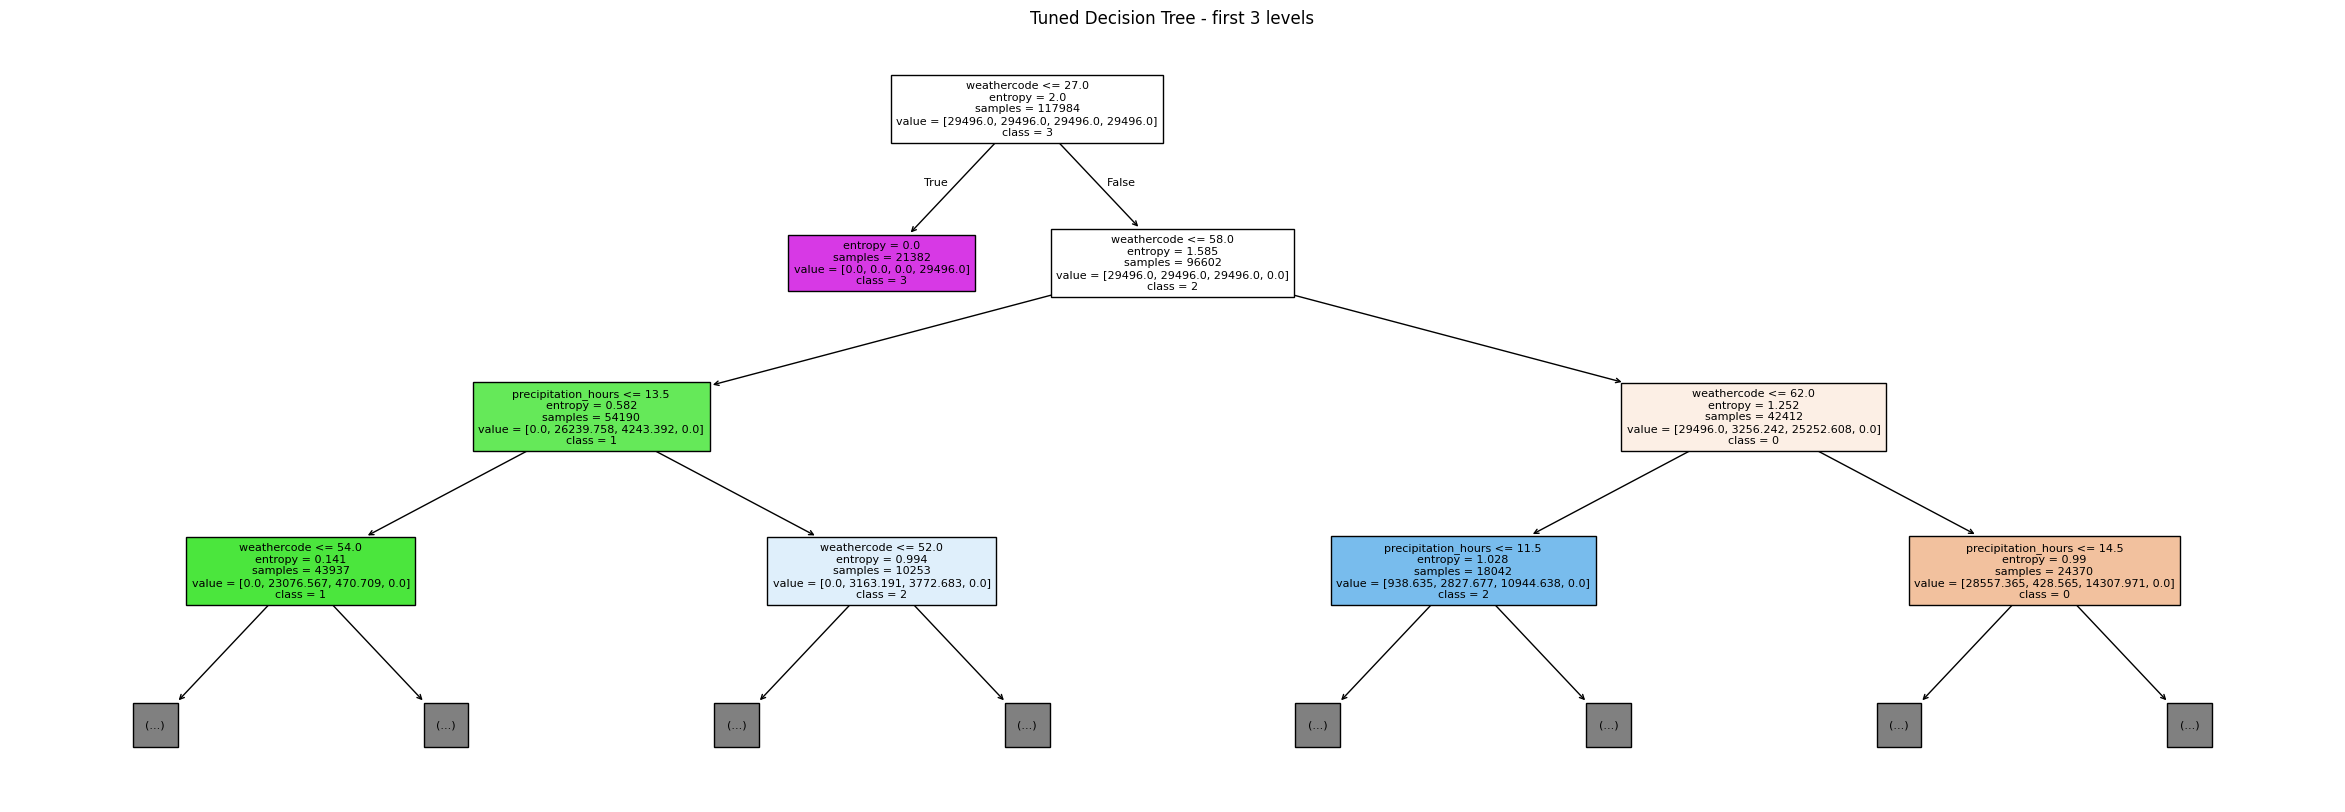

In [ ]:
# Visualization of Tuned Decision Tree
plt.figure(figsize=(30, 10))
plot_tree(
    best_tree,
    filled=True,
    max_depth=3,
    feature_names=X.columns,
    class_names=[str(c) for c in class_names],
    fontsize=8
)
plt.title("Tuned Decision Tree - first 3 levels")
plt.show()

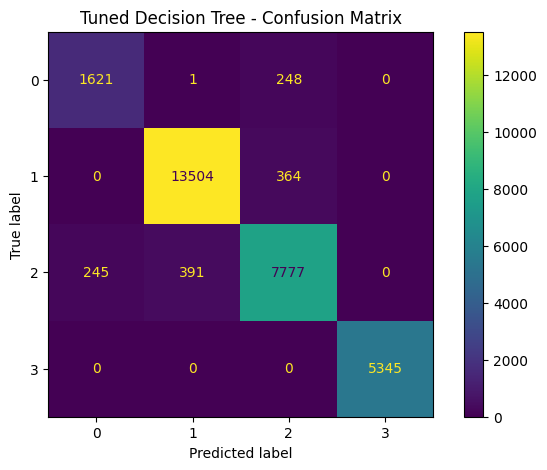

In [ ]:
# Confusion Matrix for Tuned Model
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Tuned Decision Tree - Confusion Matrix")
plt.show()

In [ ]:
# Save Trained Model
import joblib
from pathlib import Path

drive_path = Path('/content/drive/MyDrive/ML-Encorded-Dataset/')
drive_path.mkdir(parents=True, exist_ok=True)

model_save_path = drive_path / "decision_tree_model.pkl"
joblib.dump(best_tree, model_save_path)
print(f"Saved: {model_save_path}")

Saved: /content/drive/MyDrive/ML-Encorded-Dataset/decision_tree_model.pkl


In [ ]:
# Model Performance Metrics
print("Train accuracy       :", round(tree_model.score(X_train, y_train), 4))
print("Test accuracy        :", round(accuracy_score(y_test, y_pred), 4))
print("Balanced accuracy    :", round(balanced_accuracy_score(y_test, y_pred), 4))
print("Macro F1 score       :", round(f1_score(y_test, y_pred, average="macro"), 4))

Train accuracy       : 0.913
Test accuracy        : 0.9064
Balanced accuracy    : 0.91
Macro F1 score       : 0.8699


In [ ]:
# Load the saved model
loaded_model = joblib.load(model_save_path)
print(f"Loaded model from: {model_save_path}")

Loaded model from: /content/drive/MyDrive/ML-Encorded-Dataset/decision_tree_model.pkl


In [ ]:
# Enter your custom values here
# Example values provided. Modify these to your desired inputs.
custom_values = {
    'weathercode': 70.0,
    'temperature_2m_max': 28.0,
    'temperature_2m_min': 20.0,
    'temperature_2m_mean': 24.0,
    'apparent_temperature_max': 30.0,
    'apparent_temperature_min': 22.0,
    'apparent_temperature_mean': 26.0,
    'shortwave_radiation_sum': 20.0,
    'precipitation_hours': 0.0,
    'windspeed_10m_max': 10.0,
    'windgusts_10m_max': 25.0,
    'et0_fao_evapotranspiration': 4.0,
    'elevation': 100.0,
    'year': 2023.0,
    'month': 7.0,
    'day': 15.0,
    'day_of_week': 5.0,
    'quarter': 3.0,
    'is_weekend': 1.0,
    'day_length_hours': 12.5,
    'month_sin': 0.866,
    'month_cos': -0.5,
    'wind_dir_sin': 0.707,
    'wind_dir_cos': 0.707,
    'city_Colombo': 1.0
}

# Convert custom_values to a DataFrame, ensuring all model features are present
# Initialize with zeros for all feature columns
input_df = pd.DataFrame(0.0, index=[0], columns=X.columns)

# Update with user-provided custom values
for key, value in custom_values.items():
    if key in input_df.columns:
        input_df[key] = value
    else:
        print(f"Warning: Feature '{key}' from custom_values is not in the model's expected features and will be ignored.")

# Apply the same preprocessing as for the training data
# Assuming `bool_cols` and `non_numeric` were identified during initial data prep

if bool_cols:
    cols_to_convert = [col for col in bool_cols if col in input_df.columns]
    if cols_to_convert:
        input_df[cols_to_convert] = input_df[cols_to_convert].astype(int)

if non_numeric:
    cols_to_drop = [col for col in non_numeric if col in input_df.columns]
    if cols_to_drop:
        input_df = input_df.drop(columns=cols_to_drop)

print("Input data for prediction:")
display(input_df)

# Make a prediction using the loaded trained model
predicted_class_index = loaded_model.predict(input_df)[0]

# Define the mapping for decoded class names locally for this prediction
decoded_class_map = {
    0: "No Rain",
    1: "Light Rain",
    2: "Moderate Rain",
    3: "Heavy Rain"
}

# Get the decoded class name
predicted_class_name = decoded_class_map.get(predicted_class_index, f"Unknown Class Index: {predicted_class_index}")

print("\nPrediction Results:")
print(f"Predicted Rainfall Class (Encoded Value): {predicted_class_index}")
print(f"Predicted Rainfall Class (Decoded Name) : {predicted_class_name}")

Input data for prediction:


,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,et0_fao_evapotranspiration,elevation,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos,city_Athurugiriya,city_Badulla,city_Bentota,city_Colombo,city_Galle,city_Gampaha,city_Hambantota,city_Hatton,city_Jaffna,city_Kalmunai,city_Kalutara,city_Kandy,city_Kesbewa,city_Kolonnawa,city_Kurunegala,city_Mabole,city_Maharagama,city_Mannar,city_Matale,city_Matara,city_Moratuwa,city_Mount Lavinia,city_Negombo,city_Oruwala,city_Pothuhera,city_Puttalam,city_Ratnapura,city_Sri Jayewardenepura Kotte,city_Trincomalee,city_Weligama
0,70.0,28.0,20.0,24.0,30.0,22.0,26.0,20.0,0.0,10.0,25.0,4.0,100.0,2023.0,7.0,15.0,5.0,3.0,1.0,12.5,0.866,-0.5,0.707,0.707,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Prediction Results:
Predicted Rainfall Class (Encoded Value): 2
Predicted Rainfall Class (Decoded Name) : Moderate Rain


In [ ]:
# Enter your custom values here
# Example values provided. Modify these to your desired inputs.
custom_values = {
    'weathercode': 20.0,
    'temperature_2m_max': 28.0,
    'temperature_2m_min': 20.0,
    'temperature_2m_mean': 24.0,
    'apparent_temperature_max': 30.0,
    'apparent_temperature_min': 22.0,
    'apparent_temperature_mean': 26.0,
    'shortwave_radiation_sum': 20.0,
    'precipitation_hours': 0.0,
    'windspeed_10m_max': 10.0,
    'windgusts_10m_max': 25.0,
    'et0_fao_evapotranspiration': 4.0,
    'elevation': 100.0,
    'year': 2023.0,
    'month': 7.0,
    'day': 15.0,
    'day_of_week': 5.0,
    'quarter': 3.0,
    'is_weekend': 1.0,
    'day_length_hours': 12.5,
    'month_sin': 0.866,
    'month_cos': -0.5,
    'wind_dir_sin': 0.707,
    'wind_dir_cos': 0.707,
    'city_Kurunegala': 1.0
}

# Convert custom_values to a DataFrame, ensuring all model features are present
# Initialize with zeros for all feature columns
input_df = pd.DataFrame(0.0, index=[0], columns=X.columns)

# Update with user-provided custom values
for key, value in custom_values.items():
    if key in input_df.columns:
        input_df[key] = value
    else:
        print(f"Warning: Feature '{key}' from custom_values is not in the model's expected features and will be ignored.")

# Apply the same preprocessing as for the training data
# Assuming `bool_cols` and `non_numeric` were identified during initial data prep

if bool_cols:
    cols_to_convert = [col for col in bool_cols if col in input_df.columns]
    if cols_to_convert:
        input_df[cols_to_convert] = input_df[cols_to_convert].astype(int)

if non_numeric:
    cols_to_drop = [col for col in non_numeric if col in input_df.columns]
    if cols_to_drop:
        input_df = input_df.drop(columns=cols_to_drop)

print("Input data for prediction:")
display(input_df)

# Make a prediction using the loaded trained model
predicted_class_index = loaded_model.predict(input_df)[0]

# Define the mapping for decoded class names locally for this prediction
decoded_class_map = {
    0: "No Rain",
    1: "Light Rain",
    2: "Moderate Rain",
    3: "Heavy Rain"
}

# Get the decoded class name
predicted_class_name = decoded_class_map.get(predicted_class_index, f"Unknown Class Index: {predicted_class_index}")

print("\nPrediction Results:")
print(f"Predicted Rainfall Class (Encoded Value): {predicted_class_index}")
print(f"Predicted Rainfall Class (Decoded Name) : {predicted_class_name}")

Input data for prediction:


,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,shortwave_radiation_sum,precipitation_hours,windspeed_10m_max,windgusts_10m_max,et0_fao_evapotranspiration,elevation,year,month,day,day_of_week,quarter,is_weekend,day_length_hours,month_sin,month_cos,wind_dir_sin,wind_dir_cos,city_Athurugiriya,city_Badulla,city_Bentota,city_Colombo,city_Galle,city_Gampaha,city_Hambantota,city_Hatton,city_Jaffna,city_Kalmunai,city_Kalutara,city_Kandy,city_Kesbewa,city_Kolonnawa,city_Kurunegala,city_Mabole,city_Maharagama,city_Mannar,city_Matale,city_Matara,city_Moratuwa,city_Mount Lavinia,city_Negombo,city_Oruwala,city_Pothuhera,city_Puttalam,city_Ratnapura,city_Sri Jayewardenepura Kotte,city_Trincomalee,city_Weligama
0,20.0,28.0,20.0,24.0,30.0,22.0,26.0,20.0,0.0,10.0,25.0,4.0,100.0,2023.0,7.0,15.0,5.0,3.0,1.0,12.5,0.866,-0.5,0.707,0.707,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Prediction Results:
Predicted Rainfall Class (Encoded Value): 3
Predicted Rainfall Class (Decoded Name) : Heavy Rain
